In [ ]:
!pip -q install sacrebleu nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 12.9 MB/s eta 0:00:00


In [ ]:
import os
import re
import math
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
    pad_packed_sequence
)

from tqdm.auto import tqdm

#from google.colab import drive
#drive.mount('/content/drive')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu128


In [ ]:
ARABIC_DIACRITICS = re.compile(
    r'[\u064B-\u065F\u0670\u06D6-\u06ED]'
)


def normalize_arabic(text):

    text = text.strip()

    text = ARABIC_DIACRITICS.sub('', text)

    text = text.replace('أ', 'ا')
    text = text.replace('إ', 'ا')
    text = text.replace('آ', 'ا')
    text = text.replace('ى', 'ي')
    text = text.replace('ة', 'ه')
    text = text.replace('ـ', '')

    text = re.sub(
        r'([.!?؟،,])',
        r' \1 ',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


def normalize_english(text):

    text = text.lower().strip()

    text = re.sub(
        r"([.!?,])",
        r' \1 ',
        text
    )

    text = re.sub(
        r"[^a-z0-9.!?,'\s]",
        '',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


def tokenize(text):
    return text.split()

In [ ]:
!pip -q install opustools

import subprocess

SRC_LANG = "en"
TGT_LANG = "ar"
corpora = ["Tatoeba"]

for corpus in corpora:
    print(f"\n--- Downloading {corpus} ({SRC_LANG}-{TGT_LANG}) ---")
    subprocess.run([
        "opus_read",
        "-d", corpus,
        "-s", SRC_LANG,
        "-t", TGT_LANG,
        "-w", f"{corpus}.{SRC_LANG}-{TGT_LANG}.{SRC_LANG}",
              f"{corpus}.{SRC_LANG}-{TGT_LANG}.{TGT_LANG}",
        "-wm", "moses",
        "-q"
    ])



--- Downloading Tatoeba (en-ar) ---


In [ ]:
def load_pairs_from_opus(en_path, ar_path):

    pairs = []

    with open(en_path, "r", encoding="utf-8") as f_en, \
         open(ar_path, "r", encoding="utf-8") as f_ar:

        for en_line, ar_line in zip(f_en, f_ar):

            en = normalize_english(en_line.strip())
            ar = normalize_arabic(ar_line.strip())

            if ar and en:
                pairs.append((ar, en))

    return pairs


pairs = load_pairs_from_opus(
    "Tatoeba.en-ar.en",
    "Tatoeba.en-ar.ar"
)

print(f"Total samples loaded: {len(pairs):,}")

print("\nExamples:")
for ar, en in pairs[:3]:
    print("AR :", ar)
    print("EN :", en)
    print()


Total samples loaded: 32,505

Examples:
AR : لنجرب فعل شيء ما .
EN : let 's try something .

AR : لنجرب شيئا !
EN : let 's try something .

AR : علي ان انام .
EN : i have to go to sleep .



In [ ]:
def iqr_bounds(values, k=1.5):
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
en_lens = np.array([len(tokenize(en)) for ar, en in pairs])
avg_lens = (ar_lens + en_lens) / 2

low, high = iqr_bounds(avg_lens)
low = max(low, 1)  # minimum word length floor = 1

print(f"Average word count bounds: [{low:.1f}, {high:.1f}]  (raw range: {avg_lens.min():.1f}-{avg_lens.max():.1f})")

filtered_pairs = []
removed = 0

for (ar, en), avg_l in zip(pairs, avg_lens):
    if low <= avg_l <= high:
        filtered_pairs.append((ar, en))
    else:
        removed += 1

print(f"Removed {removed:,} outlier pairs out of {len(pairs):,} ({removed / len(pairs):.1%})")
print(f"Remaining: {len(filtered_pairs):,}")

pairs = filtered_pairs

Average word count bounds: [1.0, 12.0]  (raw range: 1.5-207.0)
Removed 1,445 outlier pairs out of 32,505 (4.4%)
Remaining: 31,060


In [ ]:
ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
en_lens = np.array([len(tokenize(en)) for ar, en in pairs])
en_ar_ratio = en_lens / ar_lens

low, high = iqr_bounds(en_ar_ratio)

print(f"EN/AR ratio bounds: [{low:.2f}, {high:.2f}]  (raw range: {en_ar_ratio.min():.2f}-{en_ar_ratio.max():.2f})")

filtered_pairs = []
removed = 0

for (ar, en), r in zip(pairs, en_ar_ratio):
    if low <= r <= high:
        filtered_pairs.append((ar, en))
    else:
        removed += 1

print(f"Removed {removed:,} outlier pairs out of {len(pairs):,} ({removed / len(pairs):.1%})")
print(f"Remaining: {len(filtered_pairs):,}")

pairs = filtered_pairs

EN/AR ratio bounds: [0.25, 2.25]  (raw range: 0.33-14.00)
Removed 396 outlier pairs out of 31,060 (1.3%)
Remaining: 30,664


In [ ]:
random.Random(SEED).shuffle(pairs)

n = len(pairs)

n_train = int(0.90 * n)
n_val   = int(0.05 * n)

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train + n_val]
test_pairs  = pairs[n_train + n_val:]

print(f"Train: {len(train_pairs):,}")
print(f"Val  : {len(val_pairs):,}")
print(f"Test : {len(test_pairs):,}")

Train: 27,597
Val  : 1,533
Test : 1,534


In [ ]:
class Vocab:

    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    SPECIALS = [
        "<pad>",
        "<sos>",
        "<eos>",
        "<unk>"
    ]

    def __init__(self, token_lists, min_freq=2):

        counter = Counter()

        for tokens in token_lists:
            counter.update(tokens)

        self.itos = list(self.SPECIALS)

        for token, count in counter.most_common():

            if count >= min_freq:
                self.itos.append(token)

        self.stoi = {
            token: i
            for i, token in enumerate(self.itos)
        }

    def __len__(self):
        return len(self.itos)

    def encode(
        self,
        tokens,
        add_sos=False,
        add_eos=True
    ):

        ids = [
            self.stoi.get(token, self.UNK)
            for token in tokens
        ]

        if add_sos:
            ids = [self.SOS] + ids

        if add_eos:
            ids = ids + [self.EOS]

        return ids

    def decode(self, ids):

        words = []

        for i in ids:

            if i == self.EOS:
                break

            if i in (self.PAD, self.SOS):
                continue

            if i < len(self.itos):
                words.append(self.itos[i])

        return " ".join(words)

In [ ]:
src_vocab = Vocab(
    [tokenize(ar) for ar, _ in train_pairs],
    min_freq=2
)

tgt_vocab = Vocab(
    [tokenize(en) for _, en in train_pairs],
    min_freq=2
)

print("Arabic vocab :", len(src_vocab))
print("English vocab:", len(tgt_vocab))

Arabic vocab : 8827
English vocab: 4751


In [ ]:
WORK_DIR = "/content/nmt_project"
os.makedirs(WORK_DIR, exist_ok=True)


def save_pairs(path, data):

    with open(path, "w", encoding="utf-8") as f:

        for ar, en in data:
            f.write(ar + "\t" + en + "\n")


TRAIN_FILE = f"{WORK_DIR}/train.tsv"
VAL_FILE   = f"{WORK_DIR}/val.tsv"
TEST_FILE  = f"{WORK_DIR}/test.tsv"

save_pairs(TRAIN_FILE, train_pairs)
save_pairs(VAL_FILE, val_pairs)
save_pairs(TEST_FILE, test_pairs)

print("Splits saved.")

Splits saved.


In [ ]:
class LazyNMTDataset(Dataset):

    def __init__(self, path, src_vocab, tgt_vocab):

        self.path = path
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

        self.offsets = []

        with open(path, "rb") as f:

            while True:

                pos = f.tell()
                line = f.readline()

                if not line:
                    break

                self.offsets.append(pos)

    def __len__(self):
        return len(self.offsets)

    def __getitem__(self, idx):

        with open(self.path, "rb") as f:

            f.seek(self.offsets[idx])

            line = f.readline().decode(
                "utf-8"
            ).rstrip("\n")

        ar, en = line.split("\t")

        src_ids = self.src_vocab.encode(
            tokenize(ar),
            add_sos=False,
            add_eos=True
        )

        tgt_ids = self.tgt_vocab.encode(
            tokenize(en),
            add_sos=True,
            add_eos=True
        )

        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long)
        )

In [ ]:
def collate_fn(batch):

    src, tgt = zip(*batch)

    src_lens = torch.tensor(
        [len(x) for x in src],
        dtype=torch.long
    )

    src = pad_sequence(
        src,
        batch_first=True,
        padding_value=Vocab.PAD
    )

    tgt = pad_sequence(
        tgt,
        batch_first=True,
        padding_value=Vocab.PAD
    )

    return src, src_lens, tgt

In [ ]:
class RNNEncoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        enc_hidden,
        dec_hidden,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=Vocab.PAD
        )

        self.rnn = nn.LSTM(
            embed_dim,
            enc_hidden,
            batch_first=True,
            bidirectional=True
        )

        self.fc_h = nn.Linear(
            2 * enc_hidden,
            dec_hidden
        )

        self.fc_c = nn.Linear(
            2 * enc_hidden,
            dec_hidden
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):

        emb = self.dropout(
            self.embedding(src)
        )

        packed = pack_padded_sequence(
            emb,
            src_lens.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        outputs, (h, c) = self.rnn(packed)

        outputs, _ = pad_packed_sequence(
            outputs,
            batch_first=True
        )

        h_cat = torch.cat(
            [h[0], h[1]],
            dim=1
        )

        c_cat = torch.cat(
            [c[0], c[1]],
            dim=1
        )

        h0 = torch.tanh(
            self.fc_h(h_cat)
        ).unsqueeze(0)

        c0 = torch.tanh(
            self.fc_c(c_cat)
        ).unsqueeze(0)

        return outputs, (h0, c0)

In [ ]:
class BahdanauAttention(nn.Module):

    def __init__(
        self,
        enc_hidden,
        dec_hidden,
        attn_dim
    ):
        super().__init__()

        self.W_enc = nn.Linear(
            2 * enc_hidden,
            attn_dim,
            bias=False
        )

        self.W_dec = nn.Linear(
            dec_hidden,
            attn_dim,
            bias=False
        )

        self.v = nn.Linear(
            attn_dim,
            1,
            bias=False
        )

    def forward(
        self,
        dec_h,
        enc_outputs,
        src_mask
    ):

        enc_proj = self.W_enc(
            enc_outputs
        )

        dec_proj = self.W_dec(
            dec_h
        ).unsqueeze(1)

        scores = self.v(
            torch.tanh(
                enc_proj + dec_proj
            )
        ).squeeze(-1)

        scores = scores.masked_fill(
            ~src_mask,
            float("-inf")
        )

        weights = torch.softmax(
            scores,
            dim=-1
        )

        context = torch.bmm(
            weights.unsqueeze(1),
            enc_outputs
        ).squeeze(1)

        return context, weights

In [ ]:
class RNNDecoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        enc_hidden,
        dec_hidden,
        attn_dim,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=Vocab.PAD
        )

        self.attn = BahdanauAttention(
            enc_hidden,
            dec_hidden,
            attn_dim
        )

        self.rnn = nn.LSTM(
            embed_dim + 2 * enc_hidden,
            dec_hidden,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            dec_hidden +
            2 * enc_hidden +
            embed_dim,
            vocab_size
        )

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        tgt_step,
        hidden,
        enc_outputs,
        src_mask
    ):

        emb = self.dropout(
            self.embedding(tgt_step)
        ).unsqueeze(1)

        context, attn_w = self.attn(
            hidden[0].squeeze(0),
            enc_outputs,
            src_mask
        )

        rnn_input = torch.cat(
            [
                emb,
                context.unsqueeze(1)
            ],
            dim=-1
        )

        out, hidden = self.rnn(
            rnn_input,
            hidden
        )

        out = out.squeeze(1)

        logits = self.fc_out(
            torch.cat(
                [
                    out,
                    context,
                    emb.squeeze(1)
                ],
                dim=-1
            )
        )

        return logits, hidden, attn_w

In [ ]:
class Seq2SeqRNN(nn.Module):

    def __init__(
        self,
        encoder,
        decoder
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src,
        src_lens,
        tgt,
        teacher_forcing_ratio=1.0
    ):

        B, T = tgt.shape

        vocab_size = (
            self.decoder.fc_out.out_features
        )

        src_mask = (
            src != Vocab.PAD
        )

        enc_outputs, hidden = self.encoder(
            src,
            src_lens
        )

        outputs = torch.zeros(
            B,
            T,
            vocab_size,
            device=src.device
        )

        input_step = tgt[:, 0]

        for t in range(1, T):

            logits, hidden, _ = self.decoder(
                input_step,
                hidden,
                enc_outputs,
                src_mask
            )

            outputs[:, t] = logits

            use_tf = (
                random.random()
                < teacher_forcing_ratio
            )

            input_step = (
                tgt[:, t]
                if use_tf
                else logits.argmax(-1)
            )

        return outputs

    @torch.no_grad()
    def greedy_decode(
        self,
        src,
        src_lens,
        max_len=30
    ):

        self.eval()

        src_mask = (
            src != Vocab.PAD
        )

        enc_outputs, hidden = self.encoder(
            src,
            src_lens
        )

        input_step = torch.full(
            (src.size(0),),
            Vocab.SOS,
            dtype=torch.long,
            device=src.device
        )

        tokens = []

        for _ in range(max_len):

            logits, hidden, _ = self.decoder(
                input_step,
                hidden,
                enc_outputs,
                src_mask
            )

            preds = logits.argmax(-1)

            tokens.append(preds)

            input_step = preds

        return torch.stack(
            tokens,
            dim=1
        )

In [ ]:
EMBED_DIM = 128
ENC_HIDDEN = 192
DEC_HIDDEN = 256
ATTN_DIM = 192
DROPOUT = 0.4

encoder = RNNEncoder(
    len(src_vocab),
    EMBED_DIM,
    ENC_HIDDEN,
    DEC_HIDDEN,
    DROPOUT
)

decoder = RNNDecoder(
    len(tgt_vocab),
    EMBED_DIM,
    ENC_HIDDEN,
    DEC_HIDDEN,
    ATTN_DIM,
    DROPOUT
)

model = Seq2SeqRNN(
    encoder,
    decoder
).to(device)

params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {params:,}")

Trainable parameters: 6,994,767


In [ ]:
EPOCHS = 40
LR = 5e-4
WEIGHT_DECAY = 1e-5
CLIP = 1.0
PATIENCE = 3

criterion = nn.CrossEntropyLoss(
    ignore_index=Vocab.PAD,
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

In [ ]:
def train_epoch(model, loader):

    model.train()

    total_loss = 0

    for src, src_lens, tgt in tqdm(
        loader,
        desc="Train",
        leave=False
    ):

        src = src.to(
            device,
            non_blocking=True
        )

        tgt = tgt.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        output = model(
            src,
            src_lens,
            tgt,
            teacher_forcing_ratio=1.0
        )

        output = output[:, 1:].reshape(
            -1,
            output.size(-1)
        )

        target = tgt[:, 1:].reshape(-1)

        loss = criterion(
            output,
            target
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            CLIP
        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader):

    model.eval()

    total_loss = 0

    for src, src_lens, tgt in tqdm(
        loader,
        desc="Val",
        leave=False
    ):

        src = src.to(
            device,
            non_blocking=True
        )

        tgt = tgt.to(
            device,
            non_blocking=True
        )

        output = model(
            src,
            src_lens,
            tgt,
            teacher_forcing_ratio=1.0
        )

        output = output[:, 1:].reshape(
            -1,
            output.size(-1)
        )

        target = tgt[:, 1:].reshape(-1)

        loss = criterion(
            output,
            target
        )

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
BATCH_SIZE = 64

train_ds = LazyNMTDataset(
    TRAIN_FILE,
    src_vocab,
    tgt_vocab
)

val_ds = LazyNMTDataset(
    VAL_FILE,
    src_vocab,
    tgt_vocab
)

test_ds = LazyNMTDataset(
    TEST_FILE,
    src_vocab,
    tgt_vocab
)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))
print("Train batches:", len(train_loader))

Train: 27597
Val  : 1533
Test : 1534
Train batches: 432


In [ ]:
history = {
    "train": [],
    "val": []
}

best_val = float("inf")
bad_epochs = 0

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    train_loss = train_epoch(
        model,
        train_loader
    )

    val_loss = evaluate_loss(
        model,
        val_loader
    )

    scheduler.step(val_loss)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"LR: {lr:.1e} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_loss < best_val:

        best_val = val_loss
        bad_epochs = 0

        torch.save(
            model.state_dict(),
            f"{WORK_DIR}/best_model.pt"
        )

    else:

        bad_epochs += 1

        if bad_epochs >= PATIENCE:

            print("Early stopping.")
            break


model.load_state_dict(
    torch.load(
        f"{WORK_DIR}/best_model.pt",
        map_location=device
    )
)

print(f"Best validation loss: {best_val:.4f}")

Train:   0%|          | 0/432 [00:00<?, ?it/s]

Val:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 01 | Train: 4.9881 | Val: 4.3374 | LR: 5.0e-04 | Time: 29.5s


Train:   0%|          | 0/432 [00:00<?, ?it/s]

Val:   0%|          | 0/24 [00:00<?, ?it/s]

...

Val:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 39 | Train: 1.6923 | Val: 2.8695 | LR: 6.3e-05 | Time: 22.3s


Train:   0%|          | 0/432 [00:00<?, ?it/s]

Val:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 40 | Train: 1.6882 | Val: 2.8680 | LR: 6.3e-05 | Time: 21.8s
Best validation loss: 2.8680


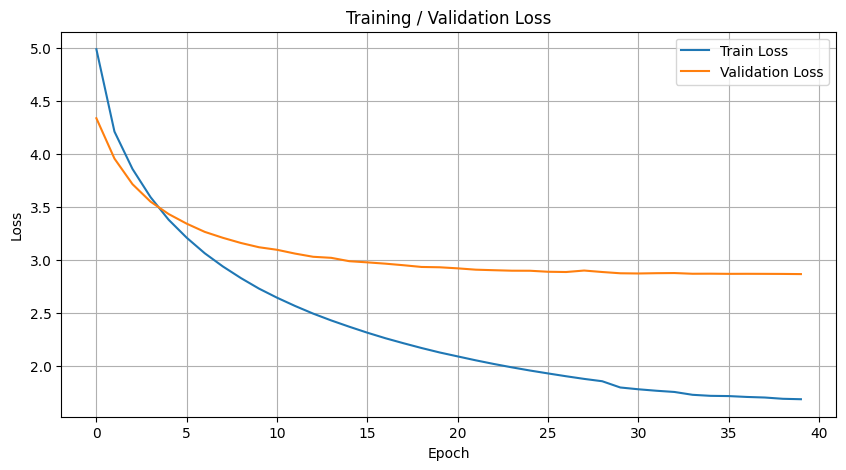

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train"],
    label="Train Loss"
)

plt.plot(
    history["val"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
@torch.no_grad()
def translate(
    model,
    arabic_sentence,
    max_len=30
):

    model.eval()

    tokens = tokenize(
        normalize_arabic(
            arabic_sentence
        )
    )

    src_ids = src_vocab.encode(
        tokens,
        add_sos=False,
        add_eos=True
    )

    src = torch.tensor(
        [src_ids],
        dtype=torch.long,
        device=device
    )

    src_lens = torch.tensor(
        [len(src_ids)],
        dtype=torch.long
    )

    src_mask = (
        src != Vocab.PAD
    )

    enc_outputs, hidden = model.encoder(
        src,
        src_lens
    )

    input_step = torch.tensor(
        [Vocab.SOS],
        dtype=torch.long,
        device=device
    )

    generated = []
    attention_weights = []

    for _ in range(max_len):

        logits, hidden, attn = model.decoder(
            input_step,
            hidden,
            enc_outputs,
            src_mask
        )

        pred = logits.argmax(-1).item()

        if pred == Vocab.EOS:
            break

        generated.append(pred)

        attention_weights.append(
            attn[0].cpu().numpy()
        )

        input_step = torch.tensor(
            [pred],
            dtype=torch.long,
            device=device
        )

    translation = tgt_vocab.decode(
        generated
    )

    return (
        translation,
        np.array(attention_weights),
        tokens
    )

In [ ]:
def show_attention(
    arabic_sentence
):

    translation, attention, src_tokens = translate(
        model,
        arabic_sentence
    )

    tgt_tokens = translation.split()

    plt.figure(
        figsize=(12, 7)
    )

    plt.imshow(
        attention,
        aspect="auto"
    )

    fixed_tokens = [fix_arabic_display(tok) for tok in src_tokens]
    plt.xticks(range(len(fixed_tokens)), fixed_tokens, rotation=45, ha="right")

    plt.yticks(
        range(len(tgt_tokens)),
        tgt_tokens
    )

    plt.xlabel(
        "Arabic Source Words"
    )

    plt.ylabel(
        "English Generated Words"
    )

    plt.title(
        "Bahdanau Attention Weights"
    )

    plt.colorbar(
        label="Attention Weight"
    )

    plt.tight_layout()
    plt.show()

    print("Arabic :", arabic_sentence)
    print("English:", translation)

In [ ]:
@torch.no_grad()
def predict_dataset(
    model,
    dataset_path
):

    references = []
    hypotheses = []

    with open(
        dataset_path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in tqdm(
            f,
            desc="Translating Test Set"
        ):

            ar, en = line.rstrip(
                "\n"
            ).split("\t")

            prediction, _, _ = translate(
                model,
                ar
            )

            references.append(en)
            hypotheses.append(
                prediction
            )

    return references, hypotheses

In [ ]:
def detokenize_en(text):
    """Undo the space-padding around punctuation added by normalize_english,
    so sacrebleu scores natural (not pre-tokenized) text as intended."""
    text = re.sub(r"\s+([.,!?'])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


references, hypotheses = predict_dataset(
    model,
    TEST_FILE
)

references_detok = [detokenize_en(r) for r in references]
hypotheses_detok = [detokenize_en(h) for h in hypotheses]

bleu = sacrebleu.corpus_bleu(
    hypotheses_detok,
    [references_detok]
)

print(f"Test BLEU: {bleu.score:.2f}")


Translating Test Set: 0it [00:00, ?it/s]

Test BLEU: 23.57


In [ ]:
@torch.no_grad()
def compute_bleu_on_loader(model, dataset_path):

    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Translating Validation Set"):

            ar, en = line.rstrip("\n").split("\t")

            prediction, _, _ = translate(model, ar)

            references.append(detokenize_en(en))
            hypotheses.append(detokenize_en(prediction))

    bleu = sacrebleu.corpus_bleu(
        hypotheses,
        [references]
    )

    return bleu


val_bleu = compute_bleu_on_loader(
    model,
    VAL_FILE
)

print(f"Validation BLEU: {val_bleu.score:.2f}")


Translating Validation Set: 0it [00:00, ?it/s]

Validation BLEU: 23.98


In [ ]:
@torch.no_grad()
def compute_sentence_bleu_table(model, dataset_path):

    rows = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Scoring sentences"):

            ar, en = line.rstrip("\n").split("\t")

            prediction, _, _ = translate(model, ar)

            ref = detokenize_en(en)
            hyp = detokenize_en(prediction)

            score = sacrebleu.sentence_bleu(hyp, [ref]).score

            rows.append({
                "arabic": ar,
                "reference": ref,
                "prediction": hyp,
                "bleu": score,
                "ref_len": len(ref.split()),
                "pred_len": len(hyp.split())
            })

    return pd.DataFrame(rows)


error_df = compute_sentence_bleu_table(model, TEST_FILE)

worst = error_df.sort_values("bleu").head(15)

print("=== 15 Worst Translations (lowest sentence BLEU) ===\n")
for _, row in worst.iterrows():
    print(f"AR : {row['arabic']}")
    print(f"REF: {row['reference']}")
    print(f"HYP: {row['prediction']}")
    print(f"BLEU: {row['bleu']:.2f} | ref_len={row['ref_len']} pred_len={row['pred_len']}")
    print()


Scoring sentences: 0it [00:00, ?it/s]

=== 15 Worst Translations (lowest sentence BLEU) ===

AR : اللعنه
REF: damn it
HYP: fuk!
BLEU: 0.00 | ref_len=2 pred_len=1

AR : لما لا تنساها و لا تتركها و شانها ؟
REF: then just forget her. leave her in peace.
HYP: why do n't you <unk> and relax?
BLEU: 0.00 | ref_len=8 pred_len=7

AR : يا لسوء حظي .
REF: how unlucky i am!
HYP: go, i'm <unk>.
BLEU: 0.00 | ref_len=4 pred_len=3

AR : في صحتك .
REF: cheers!
HYP: i'm in your health.
BLEU: 0.00 | ref_len=1 pred_len=4

AR : يوم المراه العالمي السعيد .
REF: happy international women's day!
HYP: the old woman is good good.
BLEU: 0.00 | ref_len=4 pred_len=6

AR : لا تحل المشاكل باستعمال نفس انماط التفكير التي انتجتها .
REF: we cannot solve problems with the thinking that created them
HYP: do n't <unk> your <unk> <unk>.
BLEU: 0.00 | ref_len=10 pred_len=6

AR : وداعا .
REF: farewell!
HYP: i'm good.
BLEU: 0.00 | ref_len=1 pred_len=2

AR : لنتحرك .
REF: let's move!
HYP: we were hit.
BLEU: 0.00 | ref_len=2 pred_len=3

AR : كوكب المريخ يشبه كوكبنا ف

In [ ]:
def has_repetition(text, n=2):
    tokens = text.split()
    for i in range(len(tokens) - n):
        if tokens[i:i + n] == tokens[i + n:i + 2 * n]:
            return True
    return False


short_preds = (worst["pred_len"] < worst["ref_len"] * 0.5).sum()
repeated = worst["prediction"].apply(has_repetition).sum()

print("Out of the 15 worst test examples:")
print(f" - {short_preds} have predictions under half the reference length (possible truncation / early <eos>)")
print(f" - {repeated} contain a repeated word sequence (possible decoding loop)")
print()
print(f"Overall test BLEU        : {bleu.score:.2f}")
print(f"Mean sentence BLEU (all) : {error_df['bleu'].mean():.2f}")
print(f"Mean sentence BLEU (worst 15): {worst['bleu'].mean():.2f}")


Out of the 15 worst test examples:
 - 0 have predictions under half the reference length (possible truncation / early <eos>)
 - 0 contain a repeated word sequence (possible decoding loop)

Overall test BLEU        : 23.57
Mean sentence BLEU (all) : 30.39
Mean sentence BLEU (worst 15): 1.18


In [ ]:
@torch.no_grad()
def beam_search_translate(
    model,
    arabic_sentence,
    beam_width=5,
    max_len=30,
    length_penalty=0.7
):
    model.eval()

    tokens = tokenize(normalize_arabic(arabic_sentence))
    src_ids = src_vocab.encode(tokens, add_sos=False, add_eos=True)

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_lens = torch.tensor([len(src_ids)], dtype=torch.long)
    src_mask = (src != Vocab.PAD)

    enc_outputs, hidden = model.encoder(src, src_lens)

    # each beam: (token_id_sequence, cumulative_log_prob, hidden_state)
    beams = [([Vocab.SOS], 0.0, hidden)]
    completed = []

    for _ in range(max_len):
        candidates = []

        for seq, score, hid in beams:
            if seq[-1] == Vocab.EOS:
                completed.append((seq, score))
                continue

            input_step = torch.tensor([seq[-1]], dtype=torch.long, device=device)
            logits, hid_new, _ = model.decoder(input_step, hid, enc_outputs, src_mask)
            log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)

            topk_log_probs, topk_ids = log_probs.topk(beam_width)

            for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                candidates.append((seq + [idx], score + lp, hid_new))

        if not candidates:
            break

        candidates.sort(key=lambda b: b[1] / (len(b[0]) ** length_penalty), reverse=True)
        beams = candidates[:beam_width]

        if all(seq[-1] == Vocab.EOS for seq, _, _ in beams):
            completed.extend([(seq, score) for seq, score, _ in beams])
            break

    if not completed:
        completed = [(seq, score) for seq, score, _ in beams]

    best_seq, _ = max(completed, key=lambda x: x[1] / (len(x[0]) ** length_penalty))
    generated = [t for t in best_seq if t not in (Vocab.SOS, Vocab.EOS)]

    return tgt_vocab.decode(generated)

In [ ]:
@torch.no_grad()
def evaluate_beam_search_bleu(model, dataset_path, beam_width=5):
    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Beam Search Translating"):
            ar, en = line.rstrip("\n").split("\t")
            prediction = beam_search_translate(model, ar, beam_width=beam_width)

            references.append(detokenize_en(en))
            hypotheses.append(detokenize_en(prediction))

    return sacrebleu.corpus_bleu(hypotheses, [references])


beam_bleu = evaluate_beam_search_bleu(model, TEST_FILE, beam_width=5)

print(f"Test BLEU (beam search, width=5): {beam_bleu.score:.2f}")
print(f"Test BLEU (greedy, from earlier): {bleu.score:.2f}")

Beam Search Translating: 0it [00:00, ?it/s]

Test BLEU (beam search, width=5): 26.55
Test BLEU (greedy, from earlier): 23.57


In [ ]:
!pip -q install arabic_reshaper python-bidi

import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic_display(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 11.7 MB/s eta 0:00:00


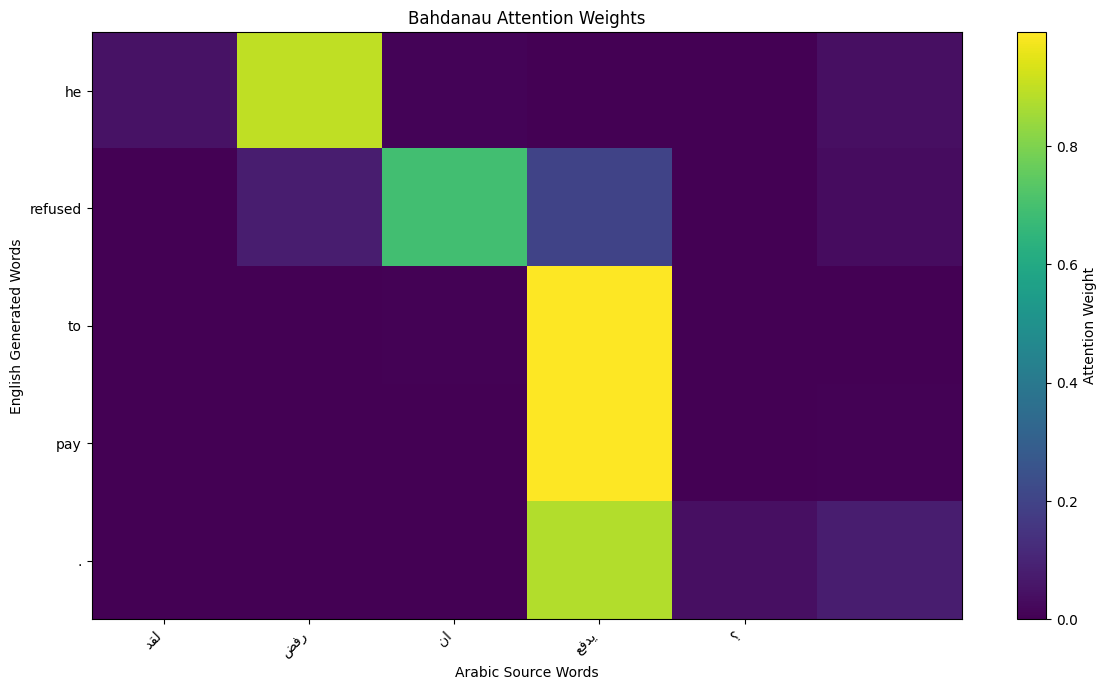

Arabic : لقد رفض ان يدفع ؟
English: he refused to pay .


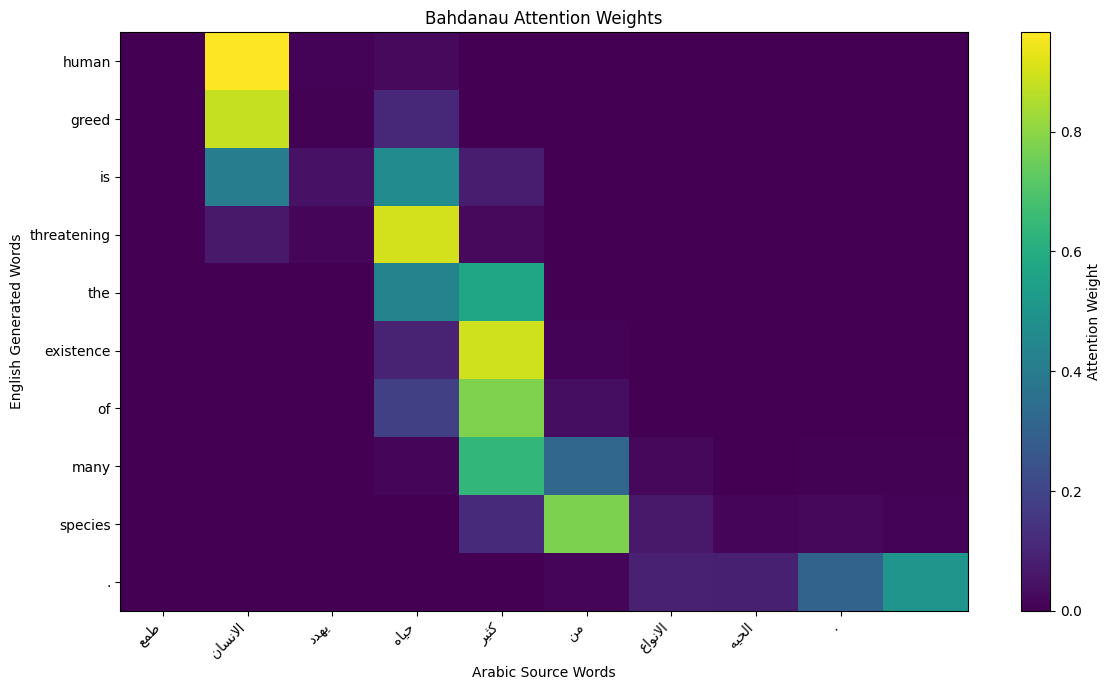

Arabic : طمع الانسان يهدد حياه كثير من الانواع الحيه .
English: human greed is threatening the existence of many species .


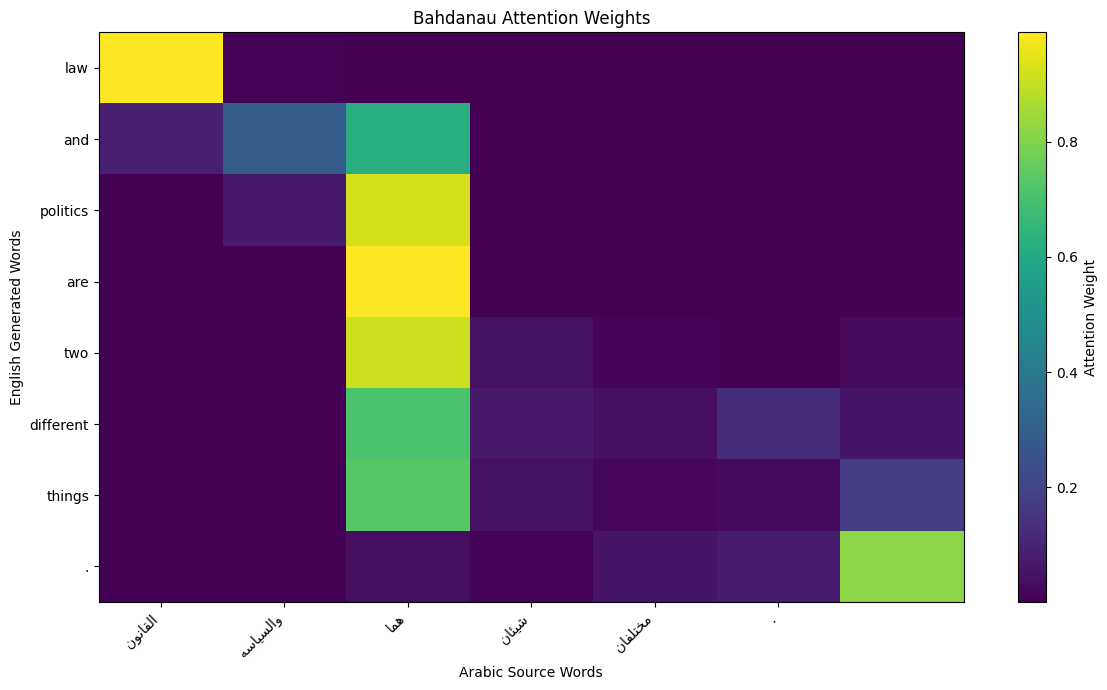

Arabic : القانون والسياسه هما شيئان مختلفان .
English: law and politics are two different things .


In [ ]:
# Attention weight visualization for a few sample sentences
sample_sentences = [
    "لقد رفض ان يدفع ؟",
    "طمع الانسان يهدد حياه كثير من الانواع الحيه .",
    "القانون والسياسه هما شيئان مختلفان .",
]

for sent in sample_sentences:
    show_attention(sent)

In [ ]:
best = error_df.sort_values("bleu", ascending=False).head(10)

print("=== Top 10 Best Translations (highest sentence BLEU) ===\n")
for _, row in best.iterrows():
    print(f"AR : {row['arabic']}")
    print(f"REF: {row['reference']}")
    print(f"HYP: {row['prediction']}")
    print(f"BLEU: {row['bleu']:.2f} | ref_len={row['ref_len']} pred_len={row['pred_len']}")
    print()

=== Top 10 Best Translations (highest sentence BLEU) ===

AR : لا مشكله علي الاطلاق !
REF: no problem at all!
HYP: no problem at all!
BLEU: 100.00 | ref_len=4 pred_len=4

AR : اراد سامي قراءه تلك الرساله .
REF: sami wanted to read the letter.
HYP: sami wanted to read the letter.
BLEU: 100.00 | ref_len=6 pred_len=6

AR : هل تظن انني غبي ؟
REF: do you think i'm stupid?
HYP: do you think i'm stupid?
BLEU: 100.00 | ref_len=5 pred_len=5

AR : فقط اخبريني ماذا تريدين .
REF: just tell me what you want.
HYP: just tell me what you want.
BLEU: 100.00 | ref_len=6 pred_len=6

AR : زيري يشاهد كره القدم .
REF: ziri watches football.
HYP: ziri watches football.
BLEU: 100.00 | ref_len=3 pred_len=3

AR : انها جاهزه الان .
REF: it's ready now.
HYP: it's ready now.
BLEU: 100.00 | ref_len=3 pred_len=3

AR : اعتقد سامي ان هذا كان مفيدا له .
REF: sami thought that that was beneficial for him.
HYP: sami thought that that was beneficial for him.
BLEU: 100.00 | ref_len=8 pred_len=8

AR : سمع زيري ريمه .
REF: z

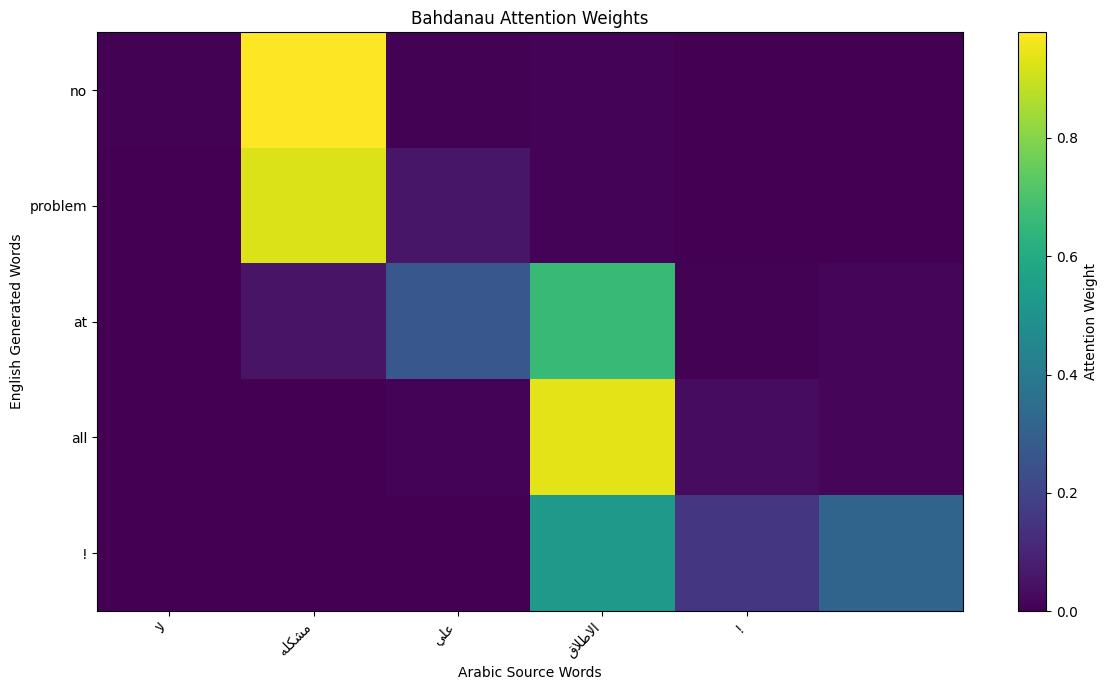

Arabic : لا مشكله علي الاطلاق !
English: no problem at all !


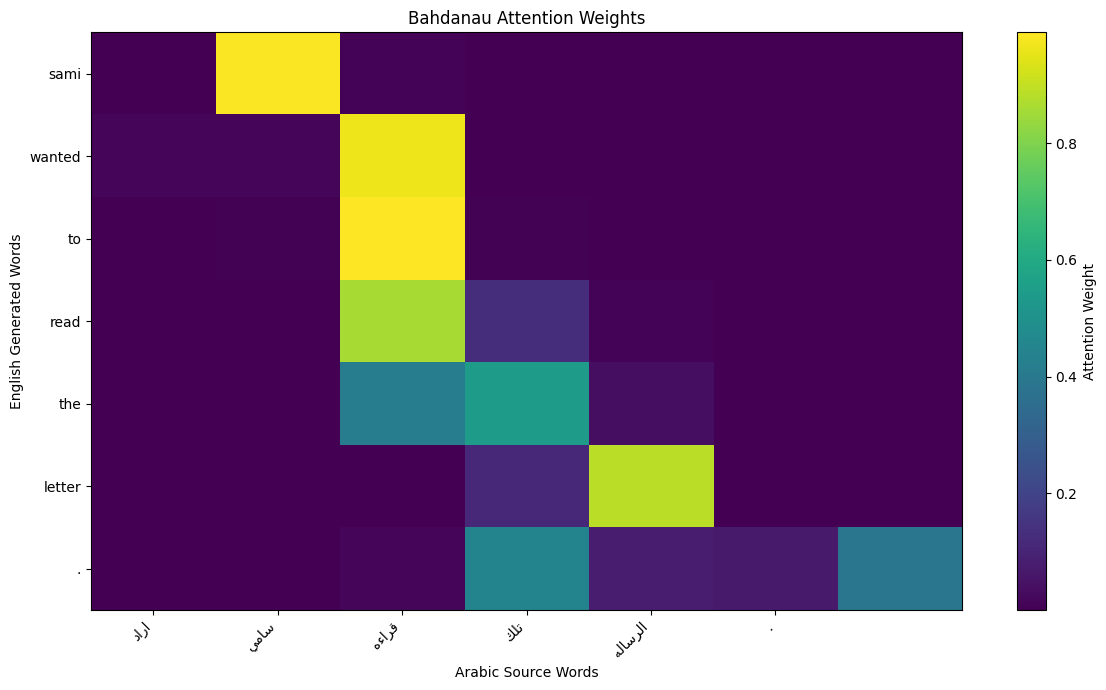

Arabic : اراد سامي قراءه تلك الرساله .
English: sami wanted to read the letter .


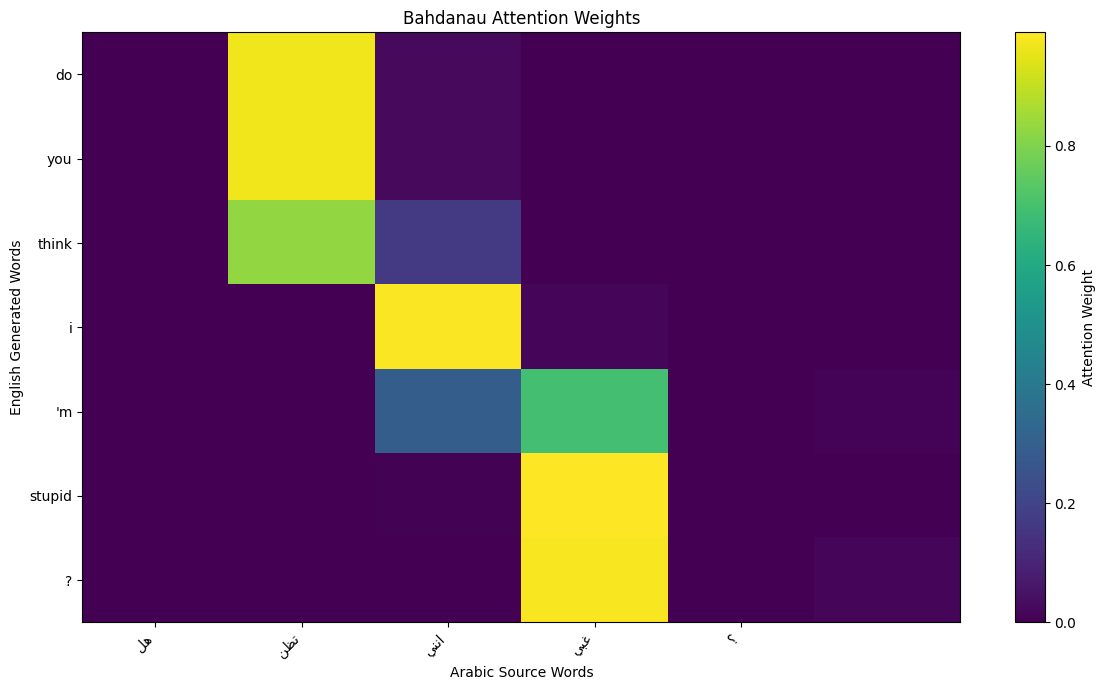

Arabic : هل تظن انني غبي ؟
English: do you think i 'm stupid ?


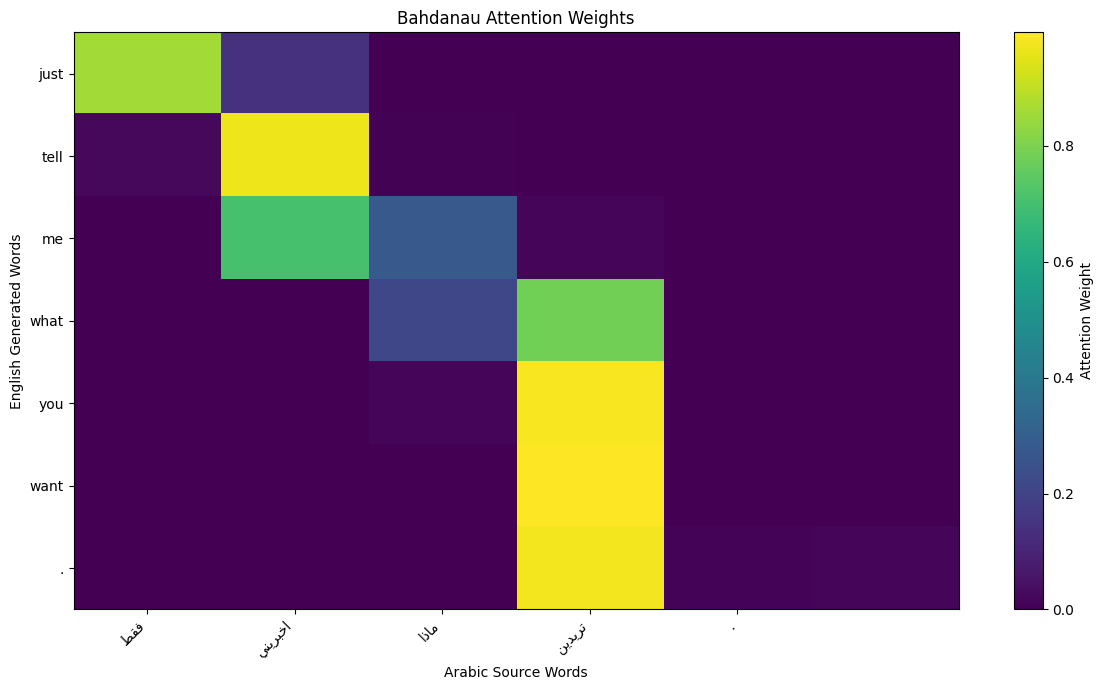

Arabic : فقط اخبريني ماذا تريدين .
English: just tell me what you want .


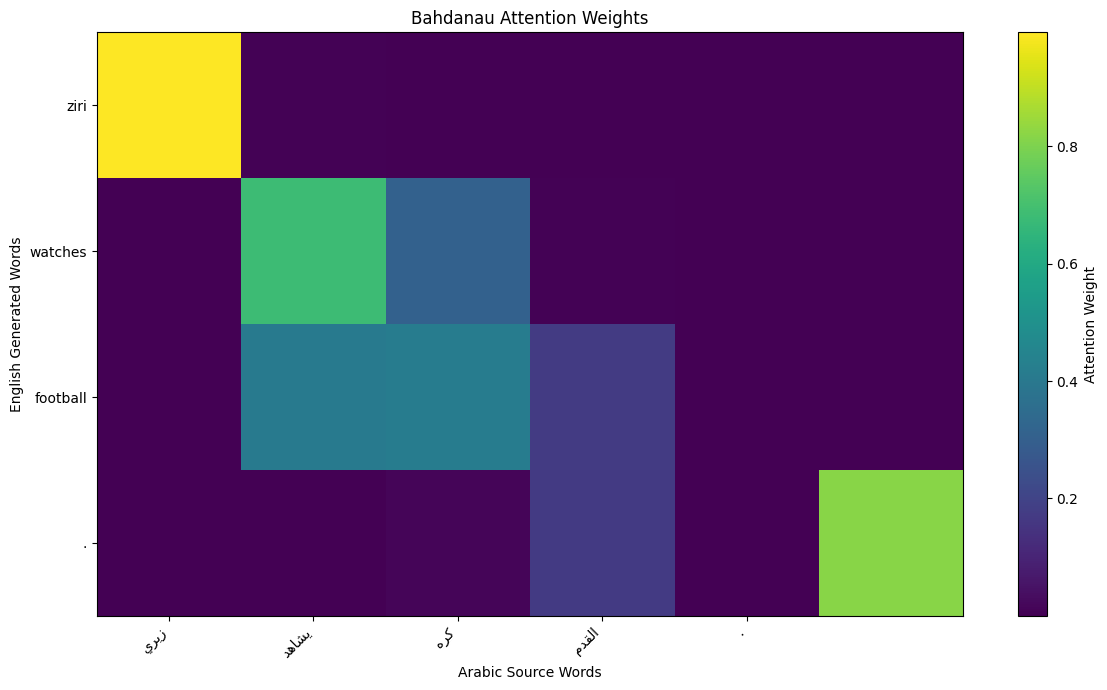

Arabic : زيري يشاهد كره القدم .
English: ziri watches football .


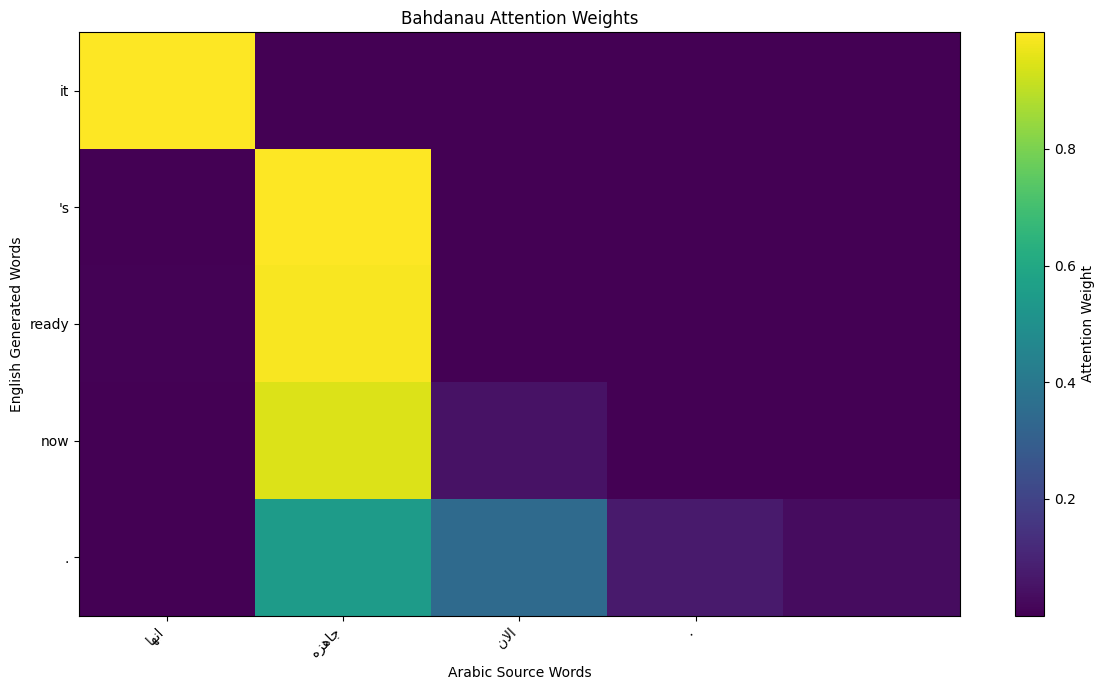

Arabic : انها جاهزه الان .
English: it 's ready now .


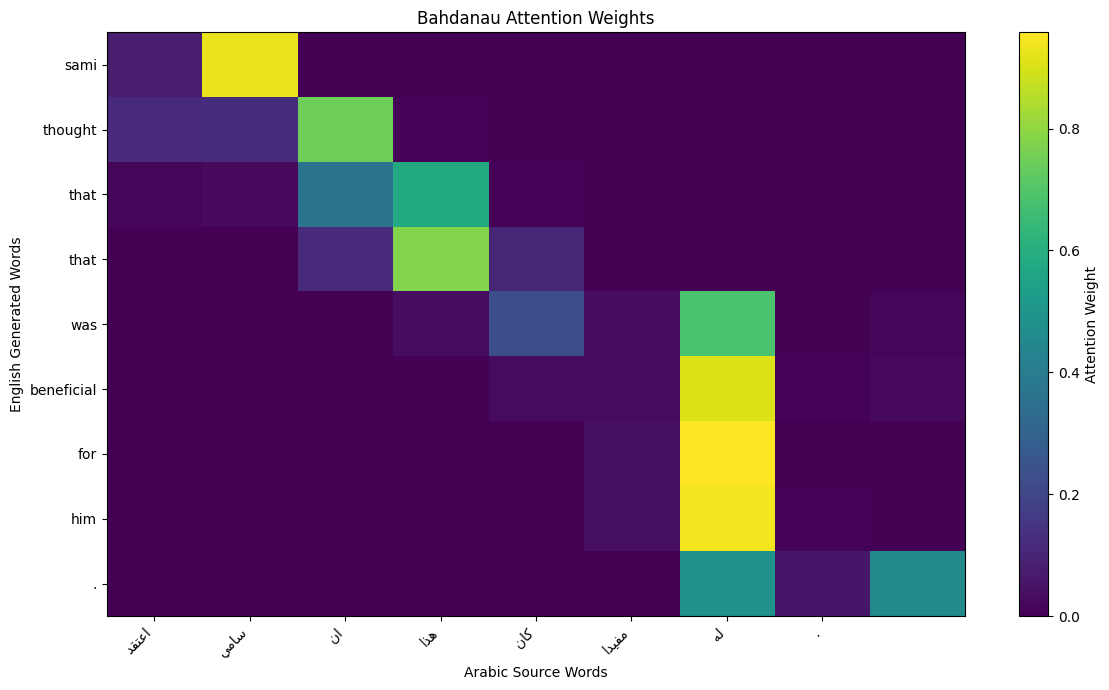

Arabic : اعتقد سامي ان هذا كان مفيدا له .
English: sami thought that that was beneficial for him .


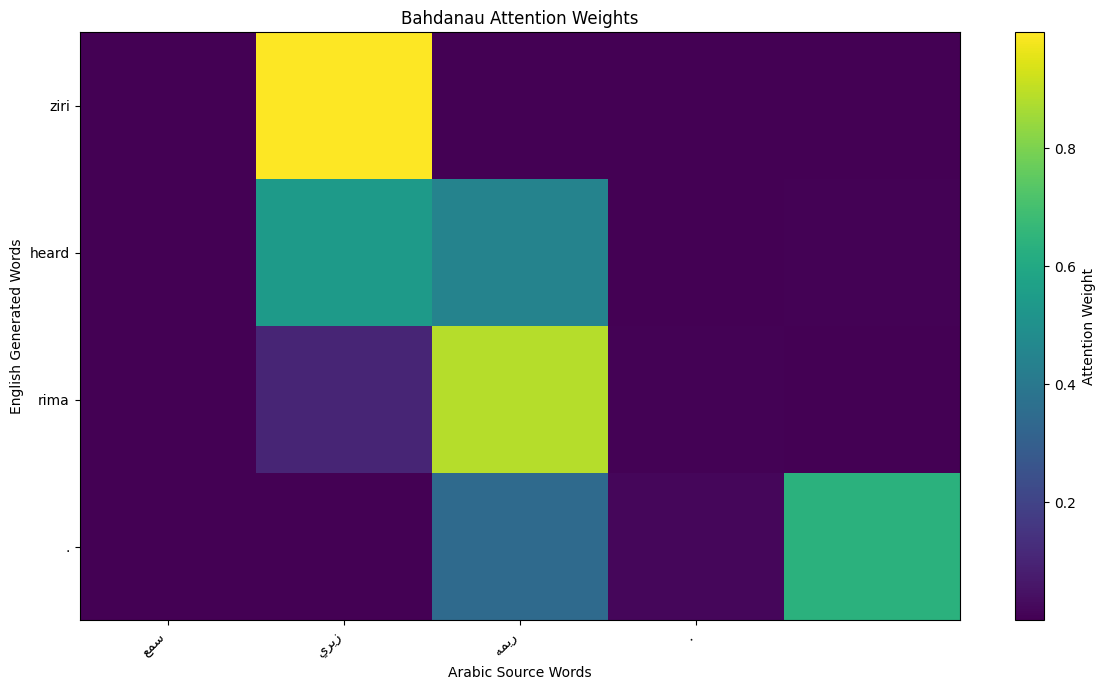

Arabic : سمع زيري ريمه .
English: ziri heard rima .


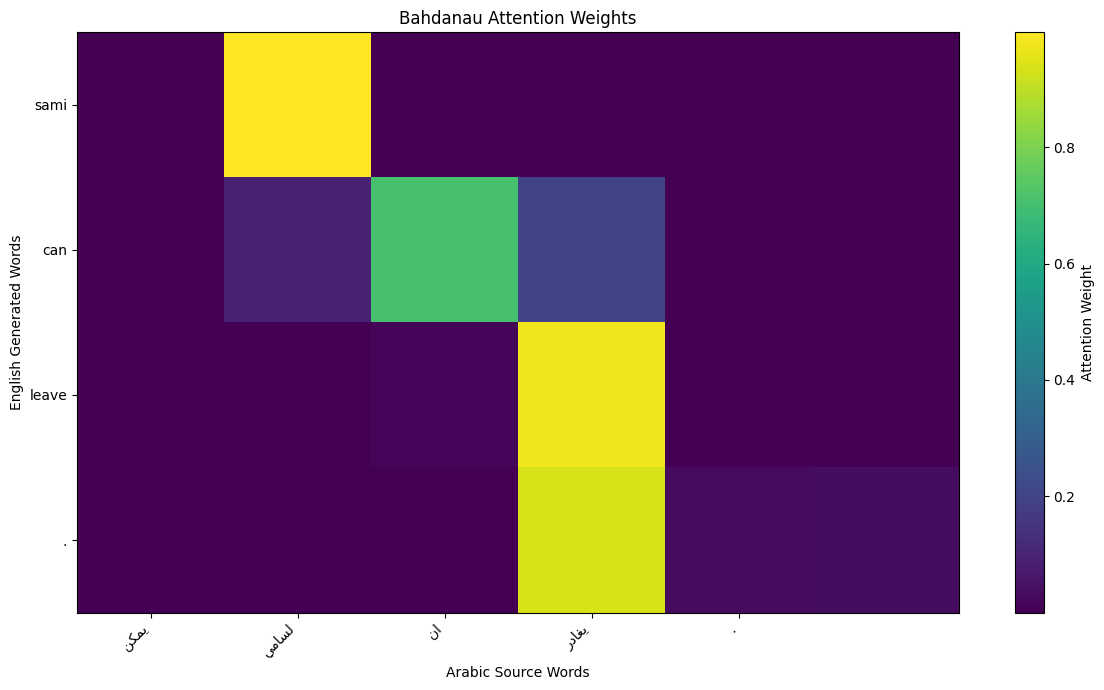

Arabic : يمكن لسامي ان يغادر .
English: sami can leave .


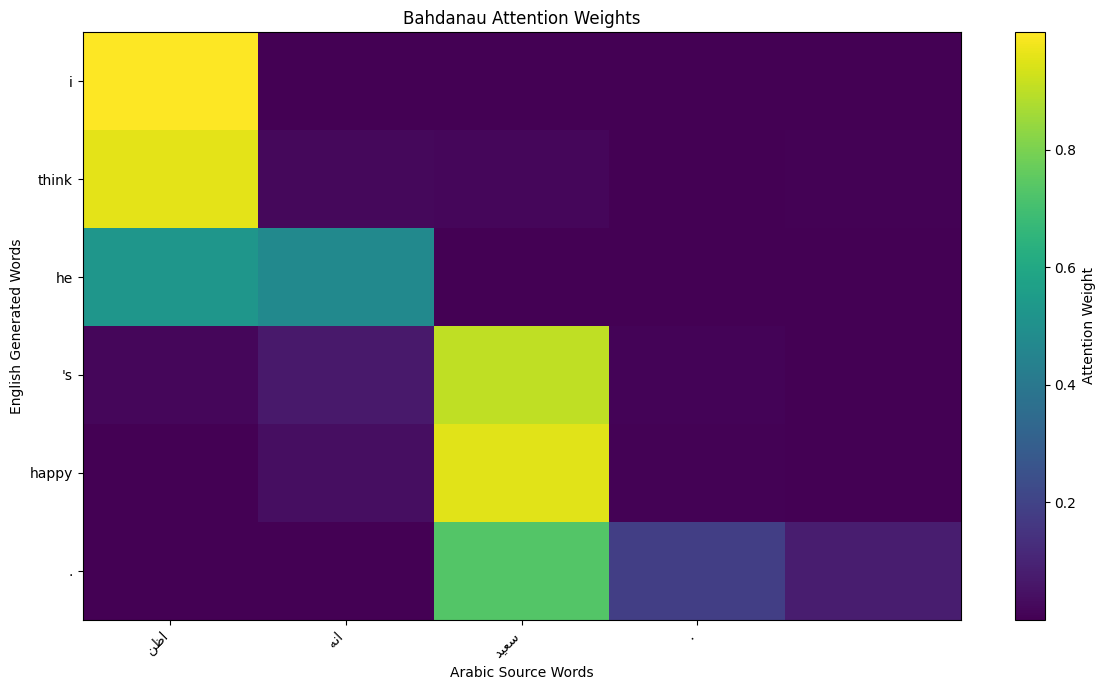

Arabic : اظن انه سعيد .
English: i think he 's happy .


In [ ]:
for sent in best["arabic"]:
    show_attention(sent)